### 数据集准备


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.font_manager import FontProperties

def _resolve_font(size: int = 10):
    """解析可用中文字体"""
    candidates = [
        Path("/System/Library/Fonts/PingFang.ttc"),
        Path("/System/Library/Fonts/Hiragino Sans GB.ttc"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return FontProperties(fname=str(candidate), size=size)
    return FontProperties(size=size)

fontProps = _resolve_font(11)
plt.rcParams["axes.unicode_minus"] = False


In [2]:
def load_dataset(csv_path: str, label_col: str, drop_cols=None):
    """
    读取银行贷款数据集，返回特征矩阵 X 和标签向量 y
    label_col: 作为分类标签的列名（这里用 Personal.Loan，即是否接受个人贷款）
    drop_cols: 不作为特征使用的列（如 ID、ZIP.Code 这种编号类字段，对距离计算没有意义）
    """
    df = pd.read_csv(csv_path)
    if drop_cols:
        df = df.drop(columns=drop_cols)

    y = df[label_col].to_numpy()
    X = df.drop(columns=[label_col]).to_numpy(dtype=float)
    feature_names = df.drop(columns=[label_col]).columns.tolist()
    return X, y, feature_names

X, y, feature_names = load_dataset(
    "../data/bankloan.csv",
    label_col="Personal.Loan",
    drop_cols=["ID", "ZIP.Code"],
)

print("特征:", feature_names)
print("样本数:", X.shape[0], "特征数:", X.shape[1])
print("正负样本比例:", np.bincount(y))


特征: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard']
样本数: 5000 特征数: 11
正负样本比例: [4520  480]


### 特征标准化

KNN 依赖样本间的距离，如果不同特征的量纲差异很大（比如 Income 是几十到几百，Family 只有 1-4），量纲大的特征会主导距离计算。所以要先手动做标准化（z-score），不借助 `sklearn.preprocessing`。


In [3]:
def standardize(X, mean=None, std=None):
    """
    对特征做 z-score 标准化: (x - mean) / std
    如果没有传入 mean/std，就用 X 自己计算（用于训练集）；
    传入训练集的 mean/std 则可以用同一套参数标准化测试集，避免数据泄漏。
    """
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
        std[std == 0] = 1.0  # 防止除0（比如某一列全是常数）
    return (X - mean) / std, mean, std


### 划分训练集/测试集

手写一个 `train_test_split`：先打乱样本索引，再按比例切分，不使用 `sklearn.model_selection`。


In [4]:
def train_test_split(X, y, test_ratio=0.2, seed=42):
    """
    手动划分训练集和测试集
    test_ratio: 测试集占比
    seed: 随机种子，保证结果可复现
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    indices = rng.permutation(n)  # 打乱索引

    n_test = int(n * test_ratio)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_ratio=0.2, seed=42)

# 只用训练集计算均值和标准差，测试集复用这套参数
X_train, mean_, std_ = standardize(X_train_raw)
X_test, _, _ = standardize(X_test_raw, mean=mean_, std=std_)

print("训练集大小:", X_train.shape, "测试集大小:", X_test.shape)


训练集大小: (4000, 11) 测试集大小: (1000, 11)


### 距离度量

KNN 最核心的一步：计算待预测样本和所有训练样本之间的距离。这里手写欧氏距离（也顺便实现曼哈顿距离，方便对比）。


In [5]:
def euclidean_distance(x1, x2):
    """
    计算两个样本之间的欧氏距离: sqrt(sum((x1_i - x2_i)^2))
    x1: 单个样本, shape=(n_features,)
    x2: 单个样本, shape=(n_features,)
    """
    diff = x1 - x2
    return np.sqrt(np.sum(diff ** 2))

def manhattan_distance(x1, x2):
    """
    曼哈顿距离: sum(|x1_i - x2_i|)
    """
    return np.sum(np.abs(x1 - x2))


### KNN 核心算法

手搓 KNN 分类器，不调用 `sklearn.neighbors.KNeighborsClassifier`。原理很简单：

1. 计算待预测样本与所有训练样本的距离
2. 按距离从小到大排序，取前 k 个最近邻
3. 统计这 k 个近邻的标签，票数最多的类别就是预测结果（多数表决，和决策树里的 `majorityCnt` 思路一致）


In [6]:
class KNNClassifier:
    """
    手写 K 近邻分类器
    k: 近邻个数
    distance_func: 单点对单点的距离度量函数，默认欧氏距离（逻辑讲解用，见 _predict_one_slow）
    """
    def __init__(self, k: int = 5, distance_func=euclidean_distance):
        self.k = k
        self.distance_func = distance_func
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        """
        KNN 是惰性学习(lazy learning)，fit阶段只是把训练数据存下来，
        真正的计算发生在predict阶段
        """
        self.X_train = X_train
        self.y_train = y_train
        return self

    def _predict_one_slow(self, x):
        """
        预测单个样本（逐个训练样本调用 distance_func，逻辑最直白，
        和"计算距离 -> 排序取前k -> 多数表决"的算法描述一一对应）
        """
        distances = np.array([self.distance_func(x, x_train) for x_train in self.X_train])
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        labels, counts = np.unique(k_labels, return_counts=True)
        return labels[np.argmax(counts)]

    def _vote(self, k_labels):
        """对 k 个近邻的标签做多数表决"""
        labels, counts = np.unique(k_labels, return_counts=True)
        return labels[np.argmax(counts)]

    def predict(self, X):
        """
        批量预测。原理和 _predict_one_slow 完全一样（算距离->排序->表决），
        只是用 numpy 广播一次性算出所有 (测试样本, 训练样本) 的距离矩阵，避免
        Python 双重 for 循环，这样几千个样本也能在可接受的时间内跑完。
        """
        # diff[i, j, :] = X[i] - X_train[j]，形状 (n_test, n_train, n_features)
        diff = X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]
        # 欧氏距离矩阵，形状 (n_test, n_train)
        distances = np.sqrt(np.sum(diff ** 2, axis=2))

        # 每一行取距离最小的 k 个训练样本下标
        k_indices = np.argsort(distances, axis=1)[:, :self.k]

        preds = np.array([self._vote(self.y_train[idx]) for idx in k_indices])
        return preds


### 模型评估

手写准确率计算，不使用 `sklearn.metrics.accuracy_score`。


In [7]:
def accuracy_score(y_true, y_pred):
    """分类准确率 = 预测正确的样本数 / 总样本数"""
    return np.mean(y_true == y_pred)

knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"k=5 时测试集准确率: {accuracy_score(y_test, y_pred):.4f}")


k=5 时测试集准确率: 0.9600


### 选择最优的 K

K 太小容易过拟合（对噪声敏感），K 太大容易欠拟合（决策边界过于平滑）。这里遍历不同的 k 值，观察测试集准确率的变化，从中选一个较优的 k。


In [8]:
k_values = list(range(1, 31))
accuracies = []

for k in k_values:
    model = KNNClassifier(k=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

best_k = k_values[int(np.argmax(accuracies))]
print(f"最优 k = {best_k}, 对应准确率 = {max(accuracies):.4f}")


最优 k = 1, 对应准确率 = 0.9610


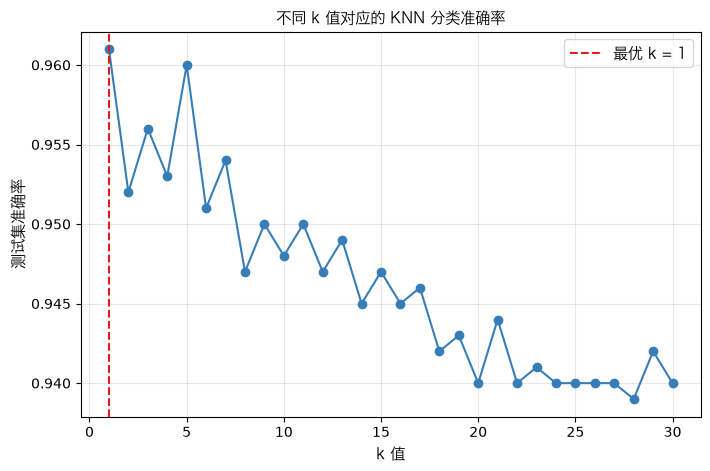

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o", color="#377eb8")
plt.axvline(best_k, color="#e41a1c", linestyle="--", label=f"最优 k = {best_k}")
plt.xlabel("k 值", fontproperties=fontProps)
plt.ylabel("测试集准确率", fontproperties=fontProps)
plt.title("不同 k 值对应的 KNN 分类准确率", fontproperties=fontProps)
plt.legend(prop=fontProps)
plt.grid(alpha=0.3)
plt.show()


### 用最优 K 重新训练并评估


In [10]:
final_model = KNNClassifier(k=best_k)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_final)

# 手写混淆矩阵，不用 sklearn.metrics.confusion_matrix
def confusion_matrix(y_true, y_pred):
    """
    二分类混淆矩阵:
              预测0   预测1
    真实0      TN      FP
    真实1      FN      TP
    """
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

cm = confusion_matrix(y_test, y_pred_final)
precision = cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0.0
recall = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0.0

print(f"最终模型 (k={best_k}) 测试集表现:")
print(f"准确率: {acc:.4f}")
print(f"精确率: {precision:.4f}")
print(f"召回率: {recall:.4f}")
print("混淆矩阵:")
print(cm)


最终模型 (k=1) 测试集表现:
准确率: 0.9610
精确率: 0.8974
召回率: 0.6931
混淆矩阵:
[[891   8]
 [ 31  70]]
